In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Square Waves

In [4]:
N = 64
dt = 1
t = np.arange(N) * dt

# create a square wave: 0, then 1's, then 0, then -1's
x = np.zeros(N)
x[1:N//2] = 1
x[N//2:N] = -1

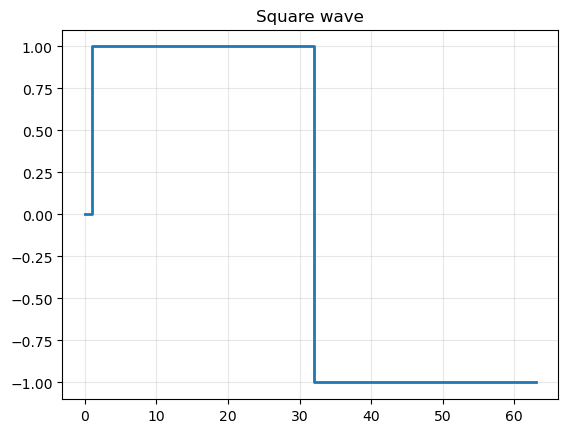

In [ ]:
plt.figure()
plt.step(t, x, where='post', linewidth=2)
plt.title('Square wave')
plt.ylim([-1.1, 1.1])
plt.grid(True, alpha=0.3)
plt.show()

#### Squre wave vs cosine with 1 cycle/record length

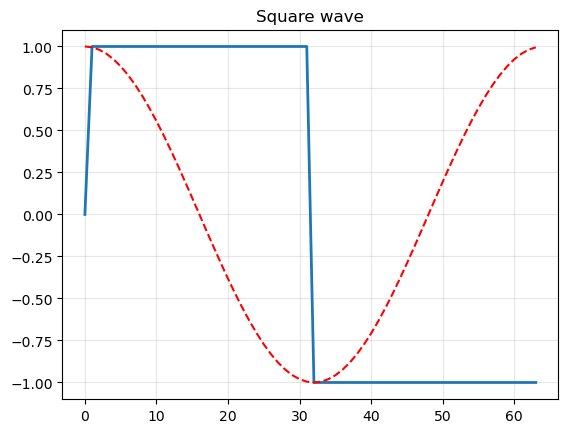

In [8]:
f = 1 / (N*dt)

plt.figure()
plt.plot(t, x, linewidth=2)
plt.plot(t, np.cos(2*np.pi*f*t), 'r--')
plt.title('Square wave')
plt.ylim([-1.1, 1.1])
plt.grid(True, alpha=0.3)
plt.show()

#### Square wave vs sine wave with 1 cycle/record length

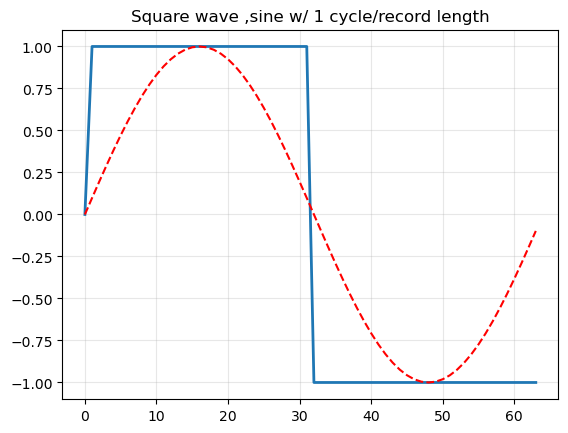

In [10]:
plt.figure()
plt.plot(t, x, linewidth=2)
plt.plot(t, np.sin(2*np.pi*t/N), 'r--')
plt.title('Square wave ,sine w/ 1 cycle/record length')
plt.ylim([-1.1, 1.1])
plt.grid(True, alpha=0.3)
plt.show()

#### square wave vs sine with 2 cycles/record length 

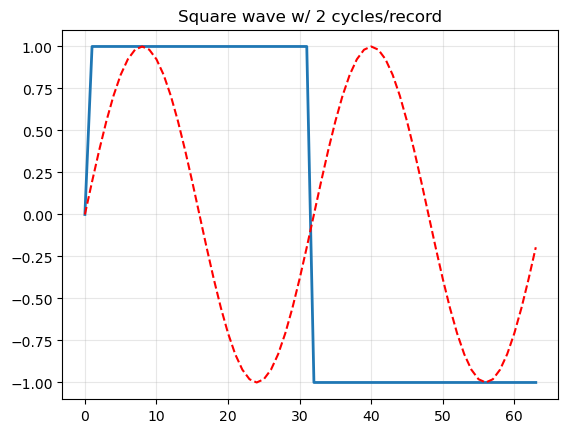

In [16]:
f = 2 / (N*dt)

plt.figure()
plt.plot(t, x, linewidth=2)
plt.plot(t, np.sin(2*np.pi*t*f), 'r--')
plt.title('Square wave w/ 2 cycles/record')
plt.ylim([-1.1, 1.1])
plt.grid(True, alpha=0.3)
plt.show()

#### Square wave, sine waves up to nyquist

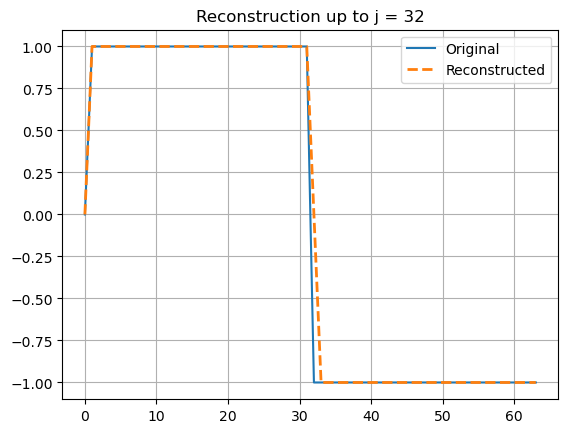

In [ ]:
y = np.zeros(N)
f = np.zeros(N // 2 + 1)
A = np.zeros(N // 2 + 1)
B = np.zeros(N // 2 + 1)

plt.figure(5)
for j in range(N // 2 + 1):
    f[j] = j / (N * dt)
    if j == 0:
        A[j] = np.sum(x)
    else:
        # Fourier Coefficients
        A[j] = 2 * np.sum(x * np.cos(2 * np.pi * f[j] * t))
        B[j] = 2 * np.sum(x * np.sin(2 * np.pi * f[j] * t))
    
    # Add the current component to the reconstruction
    y = y + (B[j] / N) * np.sin(2 * np.pi * f[j] * t)
    
plt.plot(t, x, label='Original')
plt.plot(t, y, '--', linewidth=2, label='Reconstructed')
plt.title(f'Reconstruction up to j = {N//2}')
plt.legend()
plt.grid(True)
plt.show()


#### square wave, complex ecponential / verify parsevals theorem 

#### 

In [14]:
X = np.zeros(N, dtype=complex)
y_complex = np.zeros(N, dtype=complex)

for j in range(N):
    fj = j / (N * dt)
    # Forward Transform (Analysis)
    X[j] = np.sum(x * np.exp(1j * 2 * np.pi * fj * t))
    # Inverse Transform (Synthesis)
    y_complex += (X[j] / N) * np.exp(-1j * 2 * np.pi * fj * t)

# Verify Parseval's Theorem
energy_time = np.sum(x**2)
energy_freq = (1/N) * np.sum(np.abs(X)**2)

print(f"Energy (Time Domain): {energy_time:.4f}")
print(f"Energy (Frequency Domain): {energy_freq:.4f}")
print(f"Difference: {energy_time - energy_freq:.4e}")

Energy (Time Domain): 63.0000
Energy (Frequency Domain): 63.0000
Difference: -4.2633e-14
